# Merit-order effect in the German day-ahead market (DE-LU, 2019–2025)

**Research question.** Does a higher renewable (wind + solar) generation share reduce German day-ahead
electricity prices via merit-order displacement, and has this effect strengthened between 2019–2021 and 2022–2025?

Data: ENTSO-E Transparency Platform (`entsoe-py`), bidding zone DE-LU, hourly. If `ENTSOE_API_KEY` is not set
in `.env`, the notebook runs on clearly labelled **synthetic** data so the pipeline can be validated end to end.

## 1. Setup

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.signal import lfilter
from dotenv import load_dotenv
from IPython.display import display

load_dotenv()  # reads ENTSOE_API_KEY from a local .env (never committed)
API_KEY = (os.getenv("ENTSOE_API_KEY") or "").strip()
USE_SYNTHETIC = API_KEY in {"", "your_key_here"}

COUNTRY = "DE_LU"
TZ = "Europe/Berlin"
START_YEAR, END_YEAR = 2019, 2025
START_LOCAL = pd.Timestamp(f"{START_YEAR}-01-01", tz=TZ)
END_LOCAL = pd.Timestamp(f"{END_YEAR + 1}-01-01", tz=TZ)   # exclusive
SUBPERIODS = {"2019–2021": (2019, 2021), "2022–2025": (2022, 2025)}
HAC_MAXLAGS = 168          # Newey-West truncation lag, in hours (one week)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

TAG = " [SYNTHETIC DATA]" if USE_SYNTHETIC else ""

if USE_SYNTHETIC:
    bar = "!" * 78
    print(f"{bar}\n!!{'':^74}!!\n!!{'WARNING: NO ENTSOE_API_KEY FOUND — USING SYNTHETIC DATA':^74}!!\n"
          f"!!{'Every number, plot and table below is SIMULATED, not real market data.':^74}!!\n"
          f"!!{'Set ENTSOE_API_KEY in .env and Restart & Run All for real results.':^74}!!\n!!{'':^74}!!\n{bar}")
    warnings.warn("Running on SYNTHETIC data (no ENTSOE_API_KEY set).", stacklevel=1)
else:
    print("ENTSOE_API_KEY found — using real ENTSO-E data (cached in ./data after the first pull).")

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!                                                                          !!
!!         WARNING: NO ENTSOE_API_KEY FOUND — USING SYNTHETIC DATA          !!
!!  Every number, plot and table below is SIMULATED, not real market data.  !!
!!    Set ENTSOE_API_KEY in .env and Restart & Run All for real results.    !!
!!                                                                          !!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


/tmp/ipykernel_179/607424055.py:34: UserWarning: Running on SYNTHETIC data (no ENTSOE_API_KEY set).
  warnings.warn("Running on SYNTHETIC data (no ENTSOE_API_KEY set).", stacklevel=1)


## 2. Data
**Real data.** Pulled one calendar year at a time (local time) and cached raw to `data/<series>_<year>.parquet`,
so re-runs never hit the API again. Timezone handling: raw series arrive tz-aware in Europe/Berlin; they are
converted to UTC before resampling to hourly means (UTC has no DST gaps or repeated hours; this also aggregates the
15-minute generation/load series and the 15-minute day-ahead prices introduced in October 2025). Calendar features
are then derived from the Europe/Berlin local time, so CET/CEST transition days have 23 or 25 hourly observations.
Negative prices are kept as-is — never dropped or clipped.

In [2]:
def _to_hourly_utc(obj):
    """Drop duplicate timestamps (year-boundary overlaps), convert to UTC, hourly mean."""
    obj = obj[~obj.index.duplicated(keep="first")].sort_index()
    obj.index = obj.index.tz_convert("UTC")
    return obj.resample("1h").mean()


def _cached(name, year, fetch):
    path = DATA_DIR / f"{name}_{year}.parquet"
    if path.exists():
        return pd.read_parquet(path)
    print(f"  pulling {name} {year} from ENTSO-E ...")
    df = fetch(year)
    df.to_parquet(path)
    return df


def load_real_data():
    from entsoe import EntsoePandasClient
    client = EntsoePandasClient(api_key=API_KEY)

    def bounds(y):
        return pd.Timestamp(f"{y}-01-01", tz=TZ), pd.Timestamp(f"{y + 1}-01-01", tz=TZ)

    def fetch_price(y):
        return client.query_day_ahead_prices(COUNTRY, *bounds(y)).rename("price").to_frame()

    def fetch_gen(y):
        g = client.query_generation(COUNTRY, *bounds(y), psr_type=None)
        if isinstance(g.columns, pd.MultiIndex):
            # keep generation, drop 'Actual Consumption' (e.g. pumped-storage pumping)
            g = g.xs("Actual Aggregated", axis=1, level=1)
        g.columns = [str(c) for c in g.columns]
        return g

    def fetch_load(y):
        l = client.query_load(COUNTRY, *bounds(y))
        if isinstance(l, pd.Series):
            l = l.to_frame("Actual Load")
        return l[["Actual Load"]].rename(columns={"Actual Load": "load"})

    years = range(START_YEAR, END_YEAR + 1)
    price = _to_hourly_utc(pd.concat([_cached("price", y, fetch_price) for y in years]))
    gen = _to_hourly_utc(pd.concat([_cached("generation", y, fetch_gen) for y in years]))
    load = _to_hourly_utc(pd.concat([_cached("load", y, fetch_load) for y in years]))

    needed = ["Wind Onshore", "Wind Offshore", "Solar"]
    missing = [c for c in needed if c not in gen.columns]
    if missing:
        raise KeyError(f"Generation data lacks {missing}; columns returned: {list(gen.columns)}")

    out = pd.DataFrame({
        "price": price["price"],
        "wind": gen[["Wind Onshore", "Wind Offshore"]].sum(axis=1, min_count=2),  # both must be reported
        "solar": gen["Solar"],
        "total_gen": gen.sum(axis=1, min_count=1),
        "load": load["load"],
    })
    return out  # MW and EUR/MWh, hourly, UTC index

In [3]:
def make_synthetic_data(seed=42):
    """Plausible hourly DE-LU-like data (MW, EUR/MWh). For pipeline validation ONLY."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range(START_LOCAL.tz_convert("UTC"), END_LOCAL.tz_convert("UTC"),
                        freq="1h", inclusive="left")
    local = idx.tz_convert(TZ)
    n = len(idx)
    t = np.asarray(local.year - START_YEAR + (local.dayofyear - 1) / 365.25, dtype=float)
    doy = np.asarray(local.dayofyear)
    h_local = np.asarray(local.hour)
    h_solar = np.asarray(idx.hour) + 1.5          # ~mean solar time in Germany (UTC+1, mid-hour)
    wkend = np.asarray(local.dayofweek >= 5)

    def ar1(phi, sigma):
        return lfilter([1.0], [1.0, -phi], rng.normal(0.0, sigma, n))

    # solar: growing capacity, day length + elevation shape, seasonal amplitude, persistent clouds
    season = np.sin(2 * np.pi * (doy - 80) / 365.25)
    daylen = 12 + 4.2 * season
    shape = np.clip(np.cos(np.pi * (h_solar - 12.5) / daylen), 0, None) ** 1.3
    shape[np.abs(h_solar - 12.5) > daylen / 2] = 0
    cloud = np.clip(0.75 + ar1(0.98, 0.05), 0.15, 1.0)
    solar = (45 + 7 * t) * 0.72 * shape * (0.55 + 0.4 * season) * cloud

    # wind: winter-heavy capacity factor, persistent weather regime, weak diurnal cycle
    weather = ar1(0.985, 0.025)
    cf_base = 0.21 + 0.09 * np.cos(2 * np.pi * (doy - 15) / 365.25)
    cf_on = np.clip(cf_base + weather + 0.02 * np.cos(2 * np.pi * (h_local - 14) / 24), 0.02, 0.85)
    cf_off = np.clip(cf_base + 0.15 + 1.2 * weather, 0.03, 0.95)
    wind = (53 + 1.3 * t) * cf_on + (7.5 + 0.3 * t) * cf_off

    # load: seasonal + diurnal + weekend + mild downward trend + correlated noise
    diurnal = np.where((h_local >= 6) & (h_local <= 21), 7 * np.sin(np.pi * (h_local - 5) / 17), -4)
    load = (57 - 0.5 * t + 7 * np.cos(2 * np.pi * (doy - 15) / 365.25)
            + diurnal - 7 * wkend + ar1(0.9, 0.6))

    vre = wind + solar
    exports = 2 + 0.25 * (vre - 20) / 10
    conventional = np.maximum(load + exports - vre, 12.0)   # must-run floor -> exports at high VRE
    total_gen = vre + conventional

    # price: fuel/CO2 cost regime (incl. 2021-22 gas crisis) x convex merit curve in residual load
    knots_t = [0.0, 1.0, 1.3, 2.0, 2.75, 3.0, 3.65, 3.9, 4.0, 4.5, 5.0, 6.0, 7.0]
    knots_p = [38, 34, 22, 45, 110, 220, 380, 250, 180, 100, 80, 75, 85]
    fuel = np.interp(t, knots_t, knots_p)
    residual = load - vre
    x = np.clip(residual / 50.0, 0, None)
    price = fuel * (0.25 + 0.9 * x ** 1.6)
    price -= 3.5 * np.clip(12 - residual, 0, None)            # oversupply -> negative prices
    price += 0.05 * fuel * np.isin(h_local, [18, 19, 20])
    price += fuel * ar1(0.9, 0.04) + rng.normal(0, 3, n)
    price = np.clip(price, -500, 4000)                        # SDAC harmonised price limits

    gw = 1000.0
    return pd.DataFrame({"price": price, "wind": wind * gw, "solar": solar * gw,
                         "total_gen": total_gen * gw, "load": load * gw}, index=idx)

In [4]:
raw = make_synthetic_data() if USE_SYNTHETIC else load_real_data()
raw = raw.loc[START_LOCAL.tz_convert("UTC"):END_LOCAL.tz_convert("UTC") - pd.Timedelta("1h")]
print(f"Data source: {'SYNTHETIC' if USE_SYNTHETIC else 'ENTSO-E'}{TAG}")
print(f"Hourly rows: {len(raw):,}  ({raw.index.min().tz_convert(TZ)} -> {raw.index.max().tz_convert(TZ)}, Europe/Berlin)")
print("Missing values per column:\n" + raw.isna().sum().to_string())

Data source: SYNTHETIC [SYNTHETIC DATA]
Hourly rows: 61,368  (2019-01-01 00:00:00+01:00 -> 2025-12-31 23:00:00+01:00, Europe/Berlin)
Missing values per column:
price        0
wind         0
solar        0
total_gen    0
load         0


## 3. Feature engineering
- `renewable_share = (wind + solar) / total_generation` (fraction, 0–1)
- `residual_load = load − (wind + solar)`, in **GW**
- month and hour-of-day dummies (Europe/Berlin local time; encoded in the model via `C()`, references January and hour 0)
- `negative_price` flag (day-ahead price < 0)

In [5]:
df = raw.copy()
local = df.index.tz_convert(TZ)
df["local_time"] = local
df["year"] = local.year
df["month"] = local.month
df["hour"] = local.hour
df["renewable_share"] = (df["wind"] + df["solar"]) / df["total_gen"]
df["residual_load"] = (df["load"] - (df["wind"] + df["solar"])) / 1000.0   # GW
df["negative_price"] = (df["price"] < 0).astype(int)

model_cols = ["price", "renewable_share", "residual_load", "month", "hour"]
n_before = len(df)
df = df.dropna(subset=model_cols)
df["period"] = np.where(df["year"] <= SUBPERIODS["2019–2021"][1], "2019–2021", "2022–2025")

hours_per_day = pd.Series(1, index=df["local_time"].dt.date).groupby(level=0).size()
print(f"Rows dropped for missing model inputs: {n_before - len(df):,}; rows used: {len(df):,}")
print(f"Local days with 23 h (CET->CEST): {(hours_per_day == 23).sum()}, "
      f"with 25 h (CEST->CET): {(hours_per_day == 25).sum()}")
print(f"Negative-price hours: {df['negative_price'].sum():,}  "
      f"(min price {df['price'].min():.2f} EUR/MWh) — retained in all estimations")
bad_share = ((df["renewable_share"] < 0) | (df["renewable_share"] > 1)).sum()
print(f"Hours with renewable_share outside [0, 1]: {bad_share}")

Rows dropped for missing model inputs: 0; rows used: 61,368
Local days with 23 h (CET->CEST): 7, with 25 h (CEST->CET): 7
Negative-price hours: 1,920  (min price -158.92 EUR/MWh) — retained in all estimations
Hours with renewable_share outside [0, 1]: 0


## 4. Merit-order curve
Hourly price against renewable share, coloured by sub-period, with binned means (bin width 0.04, bins with ≥ 50 hours).

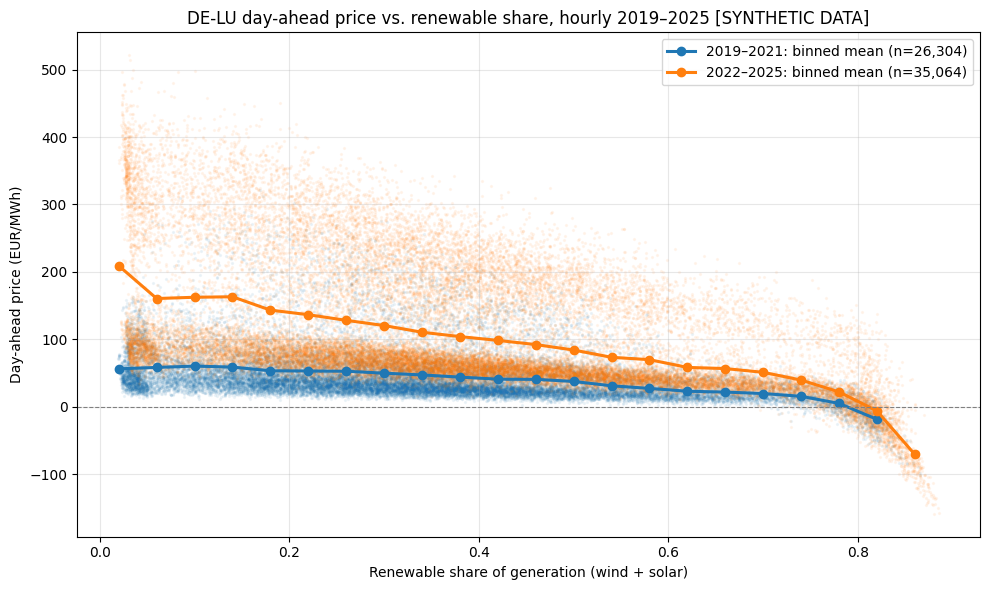

In [6]:
colors = {"2019–2021": "tab:blue", "2022–2025": "tab:orange"}
bins = np.linspace(0, 1, 26)

fig, ax = plt.subplots(figsize=(10, 6))
for p, d in df.groupby("period"):
    ax.scatter(d["renewable_share"], d["price"], s=2, alpha=0.06, color=colors[p], rasterized=True)
    g = d.groupby(pd.cut(d["renewable_share"], bins), observed=True)["price"].agg(["mean", "size"])
    g = g[g["size"] >= 50]
    mids = [iv.mid for iv in g.index]
    ax.plot(mids, g["mean"], marker="o", lw=2.2, color=colors[p], label=f"{p}: binned mean (n={len(d):,})")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("Renewable share of generation (wind + solar)")
ax.set_ylabel("Day-ahead price (EUR/MWh)")
ax.set_title(f"DE-LU day-ahead price vs. renewable share, hourly 2019–2025{TAG}")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Regression
`price ~ renewable_share + residual_load + C(month) + C(hour)`, OLS (statsmodels) with Newey-West (HAC) standard
errors, Bartlett kernel, `HAC_MAXLAGS` hours. Estimated on the full sample, then separately on 2019–2021 and 2022–2025.

In [7]:
FORMULA = "price ~ renewable_share + residual_load + C(month) + C(hour)"

def fit_hac(d):
    d = d.sort_index()
    return smf.ols(FORMULA, data=d).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_MAXLAGS})

full = fit_hac(df)
print(full.summary(title=f"Full sample 2019–2025, HAC (maxlags={HAC_MAXLAGS}){TAG}"))

          Full sample 2019–2025, HAC (maxlags=168) [SYNTHETIC DATA]           
Dep. Variable:                  price   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     26.11
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          1.61e-172
Time:                        10:08:48   Log-Likelihood:            -3.4912e+05
No. Observations:               61368   AIC:                         6.983e+05
Df Residuals:                   61331   BIC:                         6.986e+05
Df Model:                          36                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          46.5612     22.698     

In [8]:
rows = []
for label, sample in [("Full 2019–2025", df)] + [(p, df[df["period"] == p]) for p in SUBPERIODS]:
    res = full if label.startswith("Full") else fit_hac(sample)
    v = "renewable_share"
    rows.append({"sample": label, "N": int(res.nobs), "coef": res.params[v], "HAC SE": res.bse[v],
                 "t": res.tvalues[v], "p-value": res.pvalues[v], "R²": res.rsquared})
comparison = pd.DataFrame(rows).set_index("sample")

print(f"renewable_share coefficient by sample (HAC, maxlags={HAC_MAXLAGS}){TAG}")
display(comparison.round({"coef": 3, "HAC SE": 3, "t": 2, "p-value": 6, "R²": 3}))

renewable_share coefficient by sample (HAC, maxlags=168) [SYNTHETIC DATA]


,N,coef,HAC SE,t,p-value,R²
sample,,,,,,
Full 2019–2025,61368,-57.496,26.270,-2.19,0.028623,0.167
2019–2021,26304,-22.907,18.020,-1.27,0.203657,0.295
2022–2025,35064,51.721,27.111,1.91,0.056427,0.349
